# Problem 4: Kernelized SVM and Decision-Boundary Geometry

We explore how kernel choice reshapes the SVM decision boundary using two features from the Heart Disease UCI dataset:
- **x1** (`thalach`): maximum heart rate achieved (bpm)
- **x2** (`oldpeak`): ST depression induced by exercise (mm)
- **y** (`target`): 1 if heart disease, 0 otherwise

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

---
## (a) Exploratory Setup

### (a)(i) Load and Scatter

In [4]:
df = pd.read_csv('HW_2_Datasets/HW_2_Datasets/HW_4/heart_disease.csv')
print(df.shape)
print(df.head())
print(df.describe())
print(f"\nClass balance: {df['target'].value_counts().to_dict()}")

(303, 3)
   thalach  oldpeak  target
0    150.0      2.3       0
1    108.0      1.5       1
2    129.0      2.6       1
3    187.0      3.5       0
4    172.0      1.4       0
          thalach     oldpeak      target
count  303.000000  303.000000  303.000000
mean   149.607261    1.039604    0.458746
std     22.875003    1.161075    0.499120
min     71.000000    0.000000    0.000000
25%    133.500000    0.000000    0.000000
50%    153.000000    0.800000    0.000000
75%    166.000000    1.600000    1.000000
max    202.000000    6.200000    1.000000

Class balance: {0: 164, 1: 139}


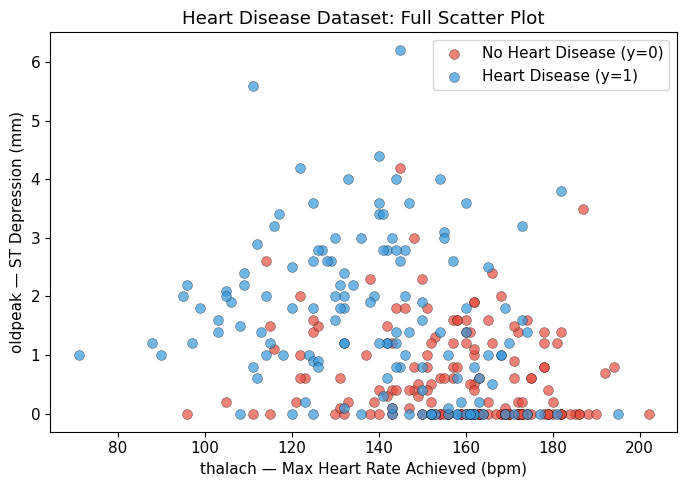


Visual inspection:
- The two classes are NOT linearly separable by eye.
- There is substantial overlap in the middle region (thalach ≈ 130–160 bpm, oldpeak ≈ 0–2 mm).
- Patients with heart disease tend toward higher heart rates and lower ST depression,
  while healthy patients cluster at lower heart rates and higher ST depression,
  but these trends overlap considerably.
- Because the data is not linearly separable, fancier (non-linear) kernels may help
  capture more complex decision boundaries.



In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = {0: '#e74c3c', 1: '#3498db'}
labels_map = {0: 'No Heart Disease (y=0)', 1: 'Heart Disease (y=1)'}

for label, group in df.groupby('target'):
    ax.scatter(group['thalach'], group['oldpeak'],
               c=colors[label], label=labels_map[label],
               alpha=0.7, edgecolors='k', linewidths=0.3, s=50)

ax.set_xlabel('thalach — Max Heart Rate Achieved (bpm)')
ax.set_ylabel('oldpeak — ST Depression (mm)')
ax.set_title('Heart Disease Dataset: Full Scatter Plot')
ax.legend()
plt.tight_layout()
plt.savefig('p4_a_scatter.png', bbox_inches='tight')
plt.show()

print("""
Visual inspection:
- The two classes are NOT linearly separable by eye.
- There is substantial overlap in the middle region (thalach ≈ 130–160 bpm, oldpeak ≈ 0–2 mm).
- Patients with heart disease tend toward higher heart rates and lower ST depression,
  while healthy patients cluster at lower heart rates and higher ST depression,
  but these trends overlap considerably.
- Because the data is not linearly separable, fancier (non-linear) kernels may help
  capture more complex decision boundaries.
""")

### (a)(ii) Train/Test Split and Standardization

In [6]:
X = df[['thalach', 'oldpeak']].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit scaler on training set ONLY, then apply to both splits
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print(f"Training set:  {X_train_std.shape[0]} samples")
print(f"Test set:      {X_test_std.shape[0]} samples")
print(f"Train mean:    {X_train_std.mean(axis=0)}  (should be ~0)")
print(f"Train std:     {X_train_std.std(axis=0)}   (should be ~1)")

print("""
Why computing μ, σ on combined train+test data is incorrect (data leakage):
  If we standardize using the full dataset's statistics, information about the test
  set (its mean and variance) leaks into the training pipeline. This means the model
  has implicitly 'seen' the test set during preprocessing, invalidating the test-set
  accuracy as an honest estimate of generalization performance. The correct protocol
  is to fit μ and σ exclusively on training data and apply those fixed values to
  transform the test set.
""")

Training set:  242 samples
Test set:      61 samples
Train mean:    [ 4.45236134e-16 -2.62875121e-16]  (should be ~0)
Train std:     [1. 1.]   (should be ~1)

Why computing μ, σ on combined train+test data is incorrect (data leakage):
  If we standardize using the full dataset's statistics, information about the test
  set (its mean and variance) leaks into the training pipeline. This means the model
  has implicitly 'seen' the test set during preprocessing, invalidating the test-set
  accuracy as an honest estimate of generalization performance. The correct protocol
  is to fit μ and σ exclusively on training data and apply those fixed values to
  transform the test set.



---
## (b) Linear SVM Baseline

### Helper: Decision Boundary Plot Function

In [7]:
def plot_decision_boundary(ax, clf, X_train_std, y_train, title,
                           show_margin=False, show_sv=False,
                           margin=0.5, resolution=300):
    """Plot a classifier's decision boundary on a 2D feature space."""
    x_min = X_train_std[:, 0].min() - margin
    x_max = X_train_std[:, 0].max() + margin
    y_min = X_train_std[:, 1].min() - margin
    y_max = X_train_std[:, 1].max() + margin

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, cmap='bwr', levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5)

    # Margin lines for linear SVM
    if show_margin and hasattr(clf, 'coef_'):
        w = clf.coef_[0]
        b = clf.intercept_[0]
        x_vals = np.linspace(x_min, x_max, 200)
        if abs(w[1]) > 1e-10:
            db   = (-w[0] * x_vals - b) / w[1]
            marg_pos = (-w[0] * x_vals - b + 1) / w[1]
            marg_neg = (-w[0] * x_vals - b - 1) / w[1]
            ax.plot(x_vals, db, 'k-', lw=2, label='Decision boundary')
            ax.plot(x_vals, marg_pos, 'k--', lw=1, label='Margin ±1')
            ax.plot(x_vals, marg_neg, 'k--', lw=1)

    # Training points
    colors = {0: '#e74c3c', 1: '#3498db'}
    for label in [0, 1]:
        mask = y_train == label
        ax.scatter(X_train_std[mask, 0], X_train_std[mask, 1],
                   c=colors[label], alpha=0.6, edgecolors='k',
                   linewidths=0.3, s=30, zorder=3)

    # Support vectors
    if show_sv and hasattr(clf, 'support_vectors_'):
        sv = clf.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none',
                   edgecolors='gold', linewidths=2, zorder=4,
                   label='Support vectors')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('thalach (standardized)')
    ax.set_ylabel('oldpeak (standardized)')
    ax.set_title(title)

### (b)(i) Decision Boundary with Margin Lines and Support Vectors

Number of support vectors: 154
  Class 0: 77, Class 1: 77


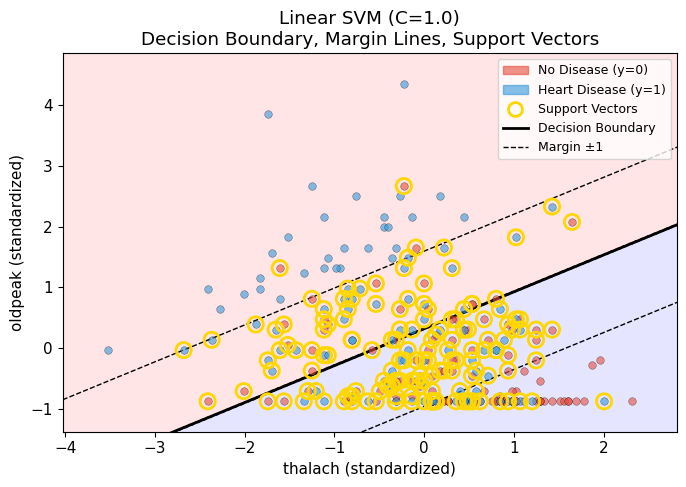


Connection to theory (Problem 1):
  The support vectors (gold circles) are precisely the training examples with
  margin m_n = y_n(w^T x_n + b) ≤ 1. These are the only examples contributing
  non-zero subgradient to the hinge-loss objective. All other training points
  (outside the margin band) have m_n > 1 and contribute zero subgradient.



In [8]:
svc_linear = SVC(kernel='linear', C=1.0)
svc_linear.fit(X_train_std, y_train)

fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(ax, svc_linear, X_train_std, y_train,
                       title='Linear SVM (C=1.0)\nDecision Boundary, Margin Lines, Support Vectors',
                       show_margin=True, show_sv=True)

# Legend patches
red_patch  = mpatches.Patch(color='#e74c3c', alpha=0.6, label='No Disease (y=0)')
blue_patch = mpatches.Patch(color='#3498db', alpha=0.6, label='Heart Disease (y=1)')
sv_handle  = plt.Line2D([0], [0], marker='o', color='w',
                         markeredgecolor='gold', markerfacecolor='none',
                         markersize=10, markeredgewidth=2, label='Support Vectors')
db_handle  = plt.Line2D([0], [0], color='k', lw=2, label='Decision Boundary')
mg_handle  = plt.Line2D([0], [0], color='k', lw=1, ls='--', label='Margin ±1')

ax.legend(handles=[red_patch, blue_patch, sv_handle, db_handle, mg_handle],
          fontsize=9, loc='upper right')

print(f"Number of support vectors: {len(svc_linear.support_vectors_)}")
print(f"  Class 0: {svc_linear.n_support_[0]}, Class 1: {svc_linear.n_support_[1]}")

plt.tight_layout()
plt.savefig('p4_b_linear_boundary.png', bbox_inches='tight')
plt.show()

print("""
Connection to theory (Problem 1):
  The support vectors (gold circles) are precisely the training examples with
  margin m_n = y_n(w^T x_n + b) ≤ 1. These are the only examples contributing
  non-zero subgradient to the hinge-loss objective. All other training points
  (outside the margin band) have m_n > 1 and contribute zero subgradient.
""")

### (b)(ii) Training and Test Accuracy

In [9]:
train_acc_linear = accuracy_score(y_train, svc_linear.predict(X_train_std))
test_acc_linear  = accuracy_score(y_test,  svc_linear.predict(X_test_std))

print(f"Linear SVM (C=1.0)")
print(f"  Training accuracy: {train_acc_linear:.4f} ({train_acc_linear*100:.1f}%)")
print(f"  Test accuracy:     {test_acc_linear:.4f} ({test_acc_linear*100:.1f}%)")

Linear SVM (C=1.0)
  Training accuracy: 0.7231 (72.3%)
  Test accuracy:     0.7705 (77.0%)


---
## (c) Polynomial Kernels

### (c)(i) Accuracy for Degrees {2, 3, 5}

In [10]:
degrees = [2, 3, 5]
poly_svcs = {}
poly_results = {}

print("Polynomial Kernel SVM (C=1.0)")
print(f"{'Degree':<10} {'Train Acc':<14} {'Test Acc':<14}")
print("-" * 38)

for d in degrees:
    clf = SVC(kernel='poly', degree=d, C=1.0, coef0=1)
    clf.fit(X_train_std, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train_std))
    te = accuracy_score(y_test,  clf.predict(X_test_std))
    poly_svcs[d] = clf
    poly_results[d] = (tr, te)
    print(f"{d:<10} {tr:.4f}         {te:.4f}")

Polynomial Kernel SVM (C=1.0)
Degree     Train Acc      Test Acc      
--------------------------------------
2          0.7190         0.7213
3          0.7273         0.7541
5          0.7355         0.7541


### (c)(ii) Decision Boundary Grid (1×3)

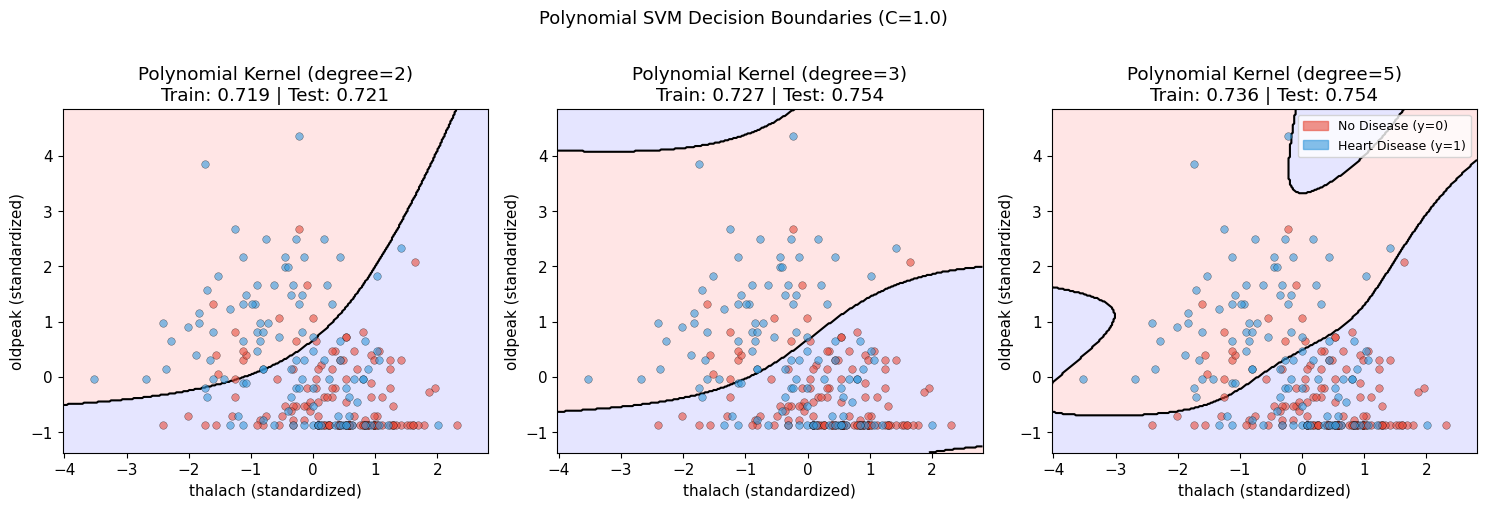


Observations on how the boundary changes with degree:

  degree=2: The boundary is a smooth conic section (ellipse/hyperbola/parabola),
  gently curving to separate the two classes. It generalizes well.

  degree=3: The boundary becomes more flexible with an S-shaped or wavy curve,
  fitting some of the intermediate overlap region more closely.

  degree=5: Overfitting starts to become visually obvious. The boundary makes
  unphysical excursions—sharp hooks and isolated islands—to chase individual
  training points. The complex shape does not reflect the underlying data
  distribution and is likely to generalize poorly on unseen data.



In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, d in zip(axes, degrees):
    clf = poly_svcs[d]
    tr, te = poly_results[d]
    plot_decision_boundary(
        ax, clf, X_train_std, y_train,
        title=f'Polynomial Kernel (degree={d})\nTrain: {tr:.3f} | Test: {te:.3f}',
        show_margin=False, show_sv=False
    )

# Shared legend
red_patch  = mpatches.Patch(color='#e74c3c', alpha=0.6, label='No Disease (y=0)')
blue_patch = mpatches.Patch(color='#3498db', alpha=0.6, label='Heart Disease (y=1)')
axes[-1].legend(handles=[red_patch, blue_patch], fontsize=9, loc='upper right')

plt.suptitle('Polynomial SVM Decision Boundaries (C=1.0)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('p4_c_poly_boundaries.png', bbox_inches='tight')
plt.show()

print("""
Observations on how the boundary changes with degree:

  degree=2: The boundary is a smooth conic section (ellipse/hyperbola/parabola),
  gently curving to separate the two classes. It generalizes well.

  degree=3: The boundary becomes more flexible with an S-shaped or wavy curve,
  fitting some of the intermediate overlap region more closely.

  degree=5: Overfitting starts to become visually obvious. The boundary makes
  unphysical excursions—sharp hooks and isolated islands—to chase individual
  training points. The complex shape does not reflect the underlying data
  distribution and is likely to generalize poorly on unseen data.
""")

---
## (d) RBF (Gaussian) Kernel

### (d)(i) Accuracy for γ ∈ {0.1, 1, 10, 100}

In [12]:
gammas = [0.1, 1, 10, 100]
rbf_svcs = {}
rbf_results = {}

print("RBF Kernel SVM (C=1.0)")
print(f"{'gamma':<10} {'Train Acc':<14} {'Test Acc':<14}")
print("-" * 38)

for g in gammas:
    clf = SVC(kernel='rbf', gamma=g, C=1.0)
    clf.fit(X_train_std, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train_std))
    te = accuracy_score(y_test,  clf.predict(X_test_std))
    rbf_svcs[g] = clf
    rbf_results[g] = (tr, te)
    print(f"{g:<10} {tr:.4f}         {te:.4f}")

RBF Kernel SVM (C=1.0)
gamma      Train Acc      Test Acc      
--------------------------------------
0.1        0.7397         0.7541
1          0.7355         0.8197
10         0.8017         0.6885
100        0.9215         0.7213


### (d)(ii) Decision Boundary Grid (2×2)

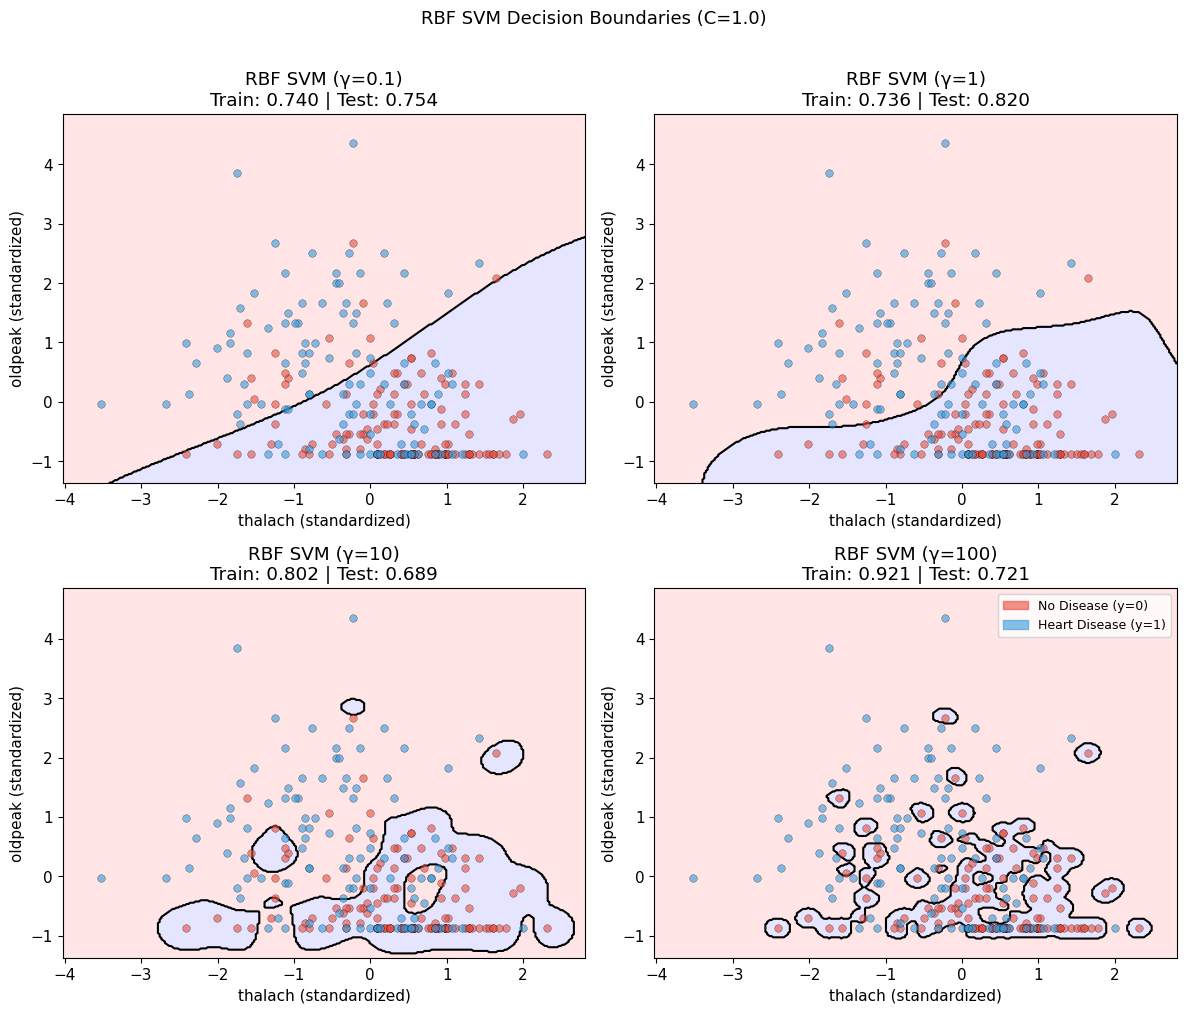

Best test accuracy: γ = 1  (train=0.736, test=0.820)
Most overfit:       γ = 100  (train=0.921, test=0.721)

Connection to Problem 2(b)(iii):
  The feature-space distance is d_k(x,z) = 2(1 - exp(-γ||x-z||²)).

  γ=0.1: The kernel decays very slowly — training points far apart still have
  high kernel similarity — so each training point influences nearly the entire
  input space. The boundary looks almost linear, and test accuracy is modest.

  γ=1: Moderate locality. The boundary curves to match the data distribution
  without overfitting badly. This is typically the sweet spot.

  γ=10: The kernel decays quickly, making the classifier local. The boundary
  becomes irregular, with small islands forming around training clusters.

  γ=100: Severe overfitting. d_k saturates at 2 for any moderately separated
  pair, so each training point only 'sees' its immediate neighbourhood.
  Training accuracy is near perfect but test accuracy collapses — the boundary
  is a patchwork of tiny decision

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.ravel()

for ax, g in zip(axes_flat, gammas):
    clf = rbf_svcs[g]
    tr, te = rbf_results[g]
    plot_decision_boundary(
        ax, clf, X_train_std, y_train,
        title=f'RBF SVM (γ={g})\nTrain: {tr:.3f} | Test: {te:.3f}',
        show_margin=False, show_sv=False
    )

# Shared legend
red_patch  = mpatches.Patch(color='#e74c3c', alpha=0.6, label='No Disease (y=0)')
blue_patch = mpatches.Patch(color='#3498db', alpha=0.6, label='Heart Disease (y=1)')
axes_flat[-1].legend(handles=[red_patch, blue_patch], fontsize=9, loc='upper right')

plt.suptitle('RBF SVM Decision Boundaries (C=1.0)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('p4_d_rbf_boundaries.png', bbox_inches='tight')
plt.show()

best_g  = max(rbf_results, key=lambda g: rbf_results[g][1])
overfit = max(rbf_results, key=lambda g: rbf_results[g][0] - rbf_results[g][1])

print(f"Best test accuracy: γ = {best_g}  "
      f"(train={rbf_results[best_g][0]:.3f}, test={rbf_results[best_g][1]:.3f})")
print(f"Most overfit:       γ = {overfit}  "
      f"(train={rbf_results[overfit][0]:.3f}, test={rbf_results[overfit][1]:.3f})")

print("""
Connection to Problem 2(b)(iii):
  The feature-space distance is d_k(x,z) = 2(1 - exp(-γ||x-z||²)).

  γ=0.1: The kernel decays very slowly — training points far apart still have
  high kernel similarity — so each training point influences nearly the entire
  input space. The boundary looks almost linear, and test accuracy is modest.

  γ=1: Moderate locality. The boundary curves to match the data distribution
  without overfitting badly. This is typically the sweet spot.

  γ=10: The kernel decays quickly, making the classifier local. The boundary
  becomes irregular, with small islands forming around training clusters.

  γ=100: Severe overfitting. d_k saturates at 2 for any moderately separated
  pair, so each training point only 'sees' its immediate neighbourhood.
  Training accuracy is near perfect but test accuracy collapses — the boundary
  is a patchwork of tiny decision regions around individual training points.
""")

---
## (e) Linking Back to Theory

### (e)(i) Loss Does Not Change the Boundary Shape

In [14]:
# Logistic regression on the same two standardized features
lr = LogisticRegression(C=1.0, max_iter=1000)
lr.fit(X_train_std, y_train)

lr_train_acc = accuracy_score(y_train, lr.predict(X_train_std))
lr_test_acc  = accuracy_score(y_test,  lr.predict(X_test_std))

print(f"Logistic Regression: train={lr_train_acc:.4f}, test={lr_test_acc:.4f}")
print(f"Linear SVM:          train={train_acc_linear:.4f}, test={test_acc_linear:.4f}")

Logistic Regression: train=0.7231, test=0.8033
Linear SVM:          train=0.7231, test=0.7705


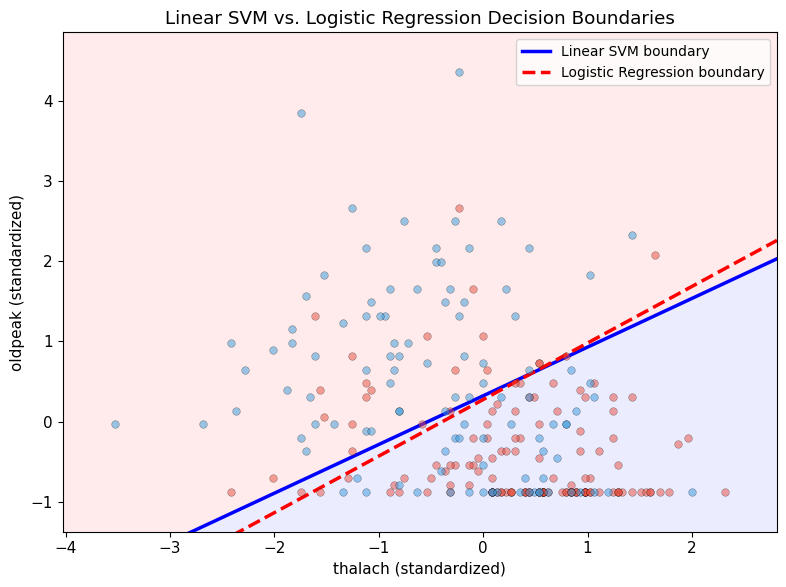


Linear SVM weights:           w = [-0.47573091  0.78303535], b = -0.2522
Logistic Regression weights:  w = [-0.60810388  0.86173062], b = -0.2372

Analysis:
  Both boundaries are straight lines in the feature space — confirming Problem 1(f):
  the form of the decision boundary (linear in x) is determined by the model class,
  not by the choice of loss function.

  They do NOT coincide exactly. This is expected: the two methods optimize different
  objectives. The linear SVM maximizes the geometric margin (finding the hyperplane
  that is farthest from both classes) using hinge loss, which only cares about
  examples within the margin. Logistic regression minimizes log-loss, which receives
  gradient contributions from every training point (as shown in Problem 1(d)).
  Because logistic loss never goes to zero, even well-classified points gently pull
  on the boundary, leading to a different orientation than the max-margin SVM.



In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

# Background: linear SVM regions
x_min = X_train_std[:, 0].min() - 0.5
x_max = X_train_std[:, 0].max() + 0.5
y_min = X_train_std[:, 1].min() - 0.5
y_max = X_train_std[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_svm = svc_linear.predict(grid).reshape(xx.shape)
ax.contourf(xx, yy, Z_svm, alpha=0.15, cmap='bwr', levels=[-0.5, 0.5, 1.5])

# Linear SVM boundary
w_svm = svc_linear.coef_[0]
b_svm = svc_linear.intercept_[0]
x_vals = np.linspace(x_min, x_max, 300)
if abs(w_svm[1]) > 1e-10:
    db_svm = (-w_svm[0] * x_vals - b_svm) / w_svm[1]
    ax.plot(x_vals, db_svm, 'b-', lw=2.5, label='Linear SVM boundary')

# Logistic Regression boundary
w_lr = lr.coef_[0]
b_lr = lr.intercept_[0]
if abs(w_lr[1]) > 1e-10:
    db_lr = (-w_lr[0] * x_vals - b_lr) / w_lr[1]
    ax.plot(x_vals, db_lr, 'r--', lw=2.5, label='Logistic Regression boundary')

# Training points
for label, color in [(0, '#e74c3c'), (1, '#3498db')]:
    mask = y_train == label
    ax.scatter(X_train_std[mask, 0], X_train_std[mask, 1],
               c=color, alpha=0.5, edgecolors='k', linewidths=0.3, s=30, zorder=3)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('thalach (standardized)')
ax.set_ylabel('oldpeak (standardized)')
ax.set_title('Linear SVM vs. Logistic Regression Decision Boundaries')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('p4_e_i_comparison.png', bbox_inches='tight')
plt.show()

print(f"\nLinear SVM weights:           w = {w_svm}, b = {b_svm:.4f}")
print(f"Logistic Regression weights:  w = {w_lr}, b = {b_lr:.4f}")

print("""
Analysis:
  Both boundaries are straight lines in the feature space — confirming Problem 1(f):
  the form of the decision boundary (linear in x) is determined by the model class,
  not by the choice of loss function.

  They do NOT coincide exactly. This is expected: the two methods optimize different
  objectives. The linear SVM maximizes the geometric margin (finding the hyperplane
  that is farthest from both classes) using hinge loss, which only cares about
  examples within the margin. Logistic regression minimizes log-loss, which receives
  gradient contributions from every training point (as shown in Problem 1(d)).
  Because logistic loss never goes to zero, even well-classified points gently pull
  on the boundary, leading to a different orientation than the max-margin SVM.
""")

### (e)(ii) Kernelized Prediction Vanishes Far From Data

In [16]:
# RBF SVM with gamma=1
svc_rbf_1 = rbf_svcs[1]

# Far-away test point: (10, 10) in standardized coordinates
x_star = np.array([[10.0, 10.0]])

# Manual computation of h(x*) = sum_{n in SV} alpha_n * y_n * k(x_n, x*) + b
# In sklearn: dual_coef_ stores alpha_n * y_n for each support vector
alpha_y = svc_rbf_1.dual_coef_[0]   # shape: (n_sv,)
sv       = svc_rbf_1.support_vectors_  # shape: (n_sv, 2)
b_rbf    = svc_rbf_1.intercept_[0]
gamma    = 1.0

# RBF kernel: k(x_n, x*) = exp(-gamma * ||x_n - x*||^2)
sq_dists = np.sum((sv - x_star) ** 2, axis=1)
k_vals   = np.exp(-gamma * sq_dists)

h_star_kernel_sum = np.dot(alpha_y, k_vals)
h_star = h_star_kernel_sum + b_rbf

print(f"RBF SVM (γ=1) prediction at x* = (10, 10):")
print(f"  Kernel sum  Σ α_n y_n k(x_n, x*) = {h_star_kernel_sum:.6f}")
print(f"  Intercept   b                      = {b_rbf:.6f}")
print(f"  h(x*)       = kernel sum + b        = {h_star:.6f}")
print(f"  |b|         = {abs(b_rbf):.6f}")
print(f"  max |k(x_n, x*)| = {k_vals.max():.2e}  (essentially 0)")

# Compare with sklearn decision_function for sanity check
h_sklearn = svc_rbf_1.decision_function(x_star)[0]
print(f"  sklearn decision_function(x*) = {h_sklearn:.6f}  (cross-check)")

print(f"""
Interpretation:
  The kernel values k(x_n, x*) = exp(-γ||x_n - x*||²) are all essentially zero
  when x* = (10, 10) is many standard deviations from every training point.
  Therefore, the kernel sum vanishes and h(x*) ≈ b (the intercept only).

  This confirms Problem 2(d): an RBF-kernel classifier of the form
  h(x) = Σ α_n k(x_n, x) + b collapses to just b when x is far from all
  training points. The classifier has virtually no meaningful confidence
  about such a point — its prediction is driven entirely by the bias term
  rather than by any actual evidence from the training data.
""")

RBF SVM (γ=1) prediction at x* = (10, 10):
  Kernel sum  Σ α_n y_n k(x_n, x*) = 0.000000
  Intercept   b                      = 0.236702
  h(x*)       = kernel sum + b        = 0.236702
  |b|         = 0.236702
  max |k(x_n, x*)| = 3.26e-58  (essentially 0)
  sklearn decision_function(x*) = 0.236702  (cross-check)

Interpretation:
  The kernel values k(x_n, x*) = exp(-γ||x_n - x*||²) are all essentially zero
  when x* = (10, 10) is many standard deviations from every training point.
  Therefore, the kernel sum vanishes and h(x*) ≈ b (the intercept only).

  This confirms Problem 2(d): an RBF-kernel classifier of the form
  h(x) = Σ α_n k(x_n, x) + b collapses to just b when x is far from all
  training points. The classifier has virtually no meaningful confidence
  about such a point — its prediction is driven entirely by the bias term
  rather than by any actual evidence from the training data.



---
## Summary Table

In [17]:
summary_rows = [
    ('Linear SVM (C=1)',            train_acc_linear, test_acc_linear),
    ('Logistic Regression (C=1)',   lr_train_acc,     lr_test_acc),
]
for d in degrees:
    tr, te = poly_results[d]
    summary_rows.append((f'Poly SVM (degree={d}, C=1)', tr, te))
for g in gammas:
    tr, te = rbf_results[g]
    summary_rows.append((f'RBF SVM (γ={g}, C=1)', tr, te))

print(f"{'Model':<35} {'Train Acc':<12} {'Test Acc':<12}")
print("-" * 59)
for name, tr, te in summary_rows:
    print(f"{name:<35} {tr:.4f}       {te:.4f}")

Model                               Train Acc    Test Acc    
-----------------------------------------------------------
Linear SVM (C=1)                    0.7231       0.7705
Logistic Regression (C=1)           0.7231       0.8033
Poly SVM (degree=2, C=1)            0.7190       0.7213
Poly SVM (degree=3, C=1)            0.7273       0.7541
Poly SVM (degree=5, C=1)            0.7355       0.7541
RBF SVM (γ=0.1, C=1)                0.7397       0.7541
RBF SVM (γ=1, C=1)                  0.7355       0.8197
RBF SVM (γ=10, C=1)                 0.8017       0.6885
RBF SVM (γ=100, C=1)                0.9215       0.7213
